<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_YB_3%EC%A1%B0_%EB%B0%A9%ED%95%99%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EA%B9%80%EB%AF%B8%EC%86%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 데이터 개요



### (1) 데이터 출처
- 제공 기관: GES DISC (Goddard Earth Sciences Data and Information Services Center)

- 데이터셋 명: MERRA-2 tavgM_2d_ocn_Nx (단축명: M2TMNXOCN)

- 버전: Version 5.12.4

- 고유 식별자 (DOI): 10.5067/4IASLIDL8EEC

### (2) 분석 기간 및 범위
- 분석 기간: 2000년 ~ 2026년

- 분석 범위: 북극(위도 60°N~90°N)


### (3) 데이터 전처리 (1차)
- NetCDF(.nc4) 형식의 원본 데이터를 Python(xarray)을 이용하여 불러왔다.

- 북극 지역(위도 60°N~90°N)만 추출하여 분석 범위를 설정하였다.

- 각 월별 자료에 대해 공간평균(Spatial Mean)을 계산하여 북극 전체를 대표하는 시계열 데이터로 변환하였다.

- 여러 개의 월별 데이터를 하나의 CSV 파일로 통합하여 분석용 데이터셋을 구축하였다.

- 분석에 필요한 변수만 선별하고 날짜(time)를 datetime 형식으로 변환한 후 오름차순으로 정렬하여 최종 분석 데이터를 생성하였다.











### (4) 변수
- time : 관측 시간 (년-월)

- FRSEAICE : 북극 해빙 면적 비율 (해당 해역에 바다 얼음이 덮여있는 비율)

- TSKINWTR : 해수면 온도 (얼음이 없는 순수한 바닷물의 온도)

- T10M : 10m 상공의 기온 (바다 위 대기 온도)

- HFLUXWTR : 해수면의 현열 플럭스 (대기와 바닷물의 온도 차이로 주고받는 열에너지)

- EFLUXWTR : 해수면의 잠열 플럭스 (바닷물이 증발할 때 발생하는 열에너지)

- U10M : 10m 상공의 동서 방향 바람 속도

- V10M : 10m 상공의 남북 방향 바람 속도

※ 현열 플럭스는 바다와 대기의 온도 차이에 의해 전달되는 열에너지이며, 잠열 플럭스는 해수의 증발 과정에서 전달되는 열에너지를 의미한다.


# 2. EDA

In [1]:
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rc('font', family='NanumGothic')


# 데이터 불러오기 및 전처리
file_path = '/content/drive/MyDrive/YB_data/Arctic_SST_Analysis_Data.csv'
df = pd.read_csv(file_path)

# 시간 인덱스 설정 및 파생 변수(연/월) 생성
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df['Year'] = df.index.year
df['Month'] = df.index.month

# 공통 파생 변수(이동평균) 미리 계산
df['TSKINWTR_roll'] = df['TSKINWTR'].rolling(window=12, center=True).mean()

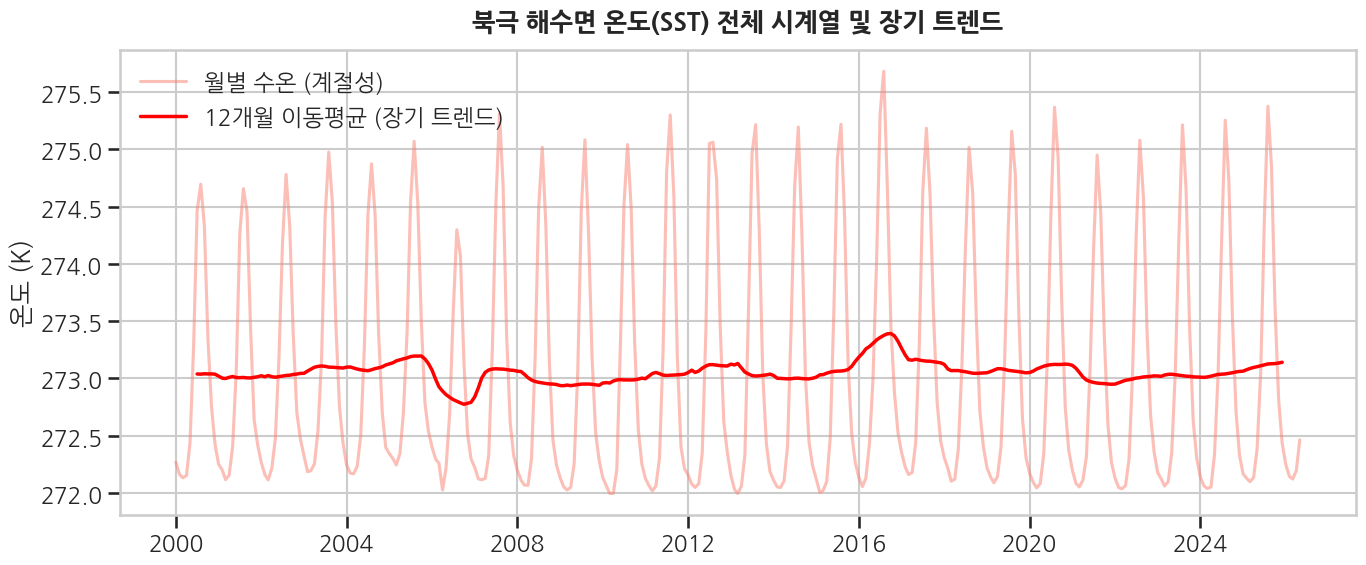

In [2]:
# [그래프 1] 북극 해수면 온도(SST) 전체 시계열 및 장기 트렌드
plt.figure(figsize=(14, 6))

# 원본 데이터와 이동평균선
plt.plot(df.index, df['TSKINWTR'], color='salmon', alpha=0.5, label='월별 수온 (계절성)')
plt.plot(df.index, df['TSKINWTR_roll'], color='red', linewidth=2.5, label='12개월 이동평균 (장기 트렌드)')

# 제목 및 축 이름 설정
plt.title('북극 해수면 온도(SST) 전체 시계열 및 장기 트렌드', fontweight='bold', pad=15)
plt.ylabel('온도 (K)')
plt.legend()
plt.tight_layout()

plt.show()

[그래프 1]
- 뚜렷한 계절성: 연한 붉은 선이 일정한 주기로 오르락내리락하는 것은 북극해의 여름과 겨울이 반복되는 자연스러운 현상이다.

- 수온 상승 (온난화 추세): 진한 붉은 선(12개월 이동평균)을 보면, 2000년대 초반에 비해 2016년 무렵 수온이 가장 높게 치솟았으며 전체적인 베이스라인이 미세하게 우상향하고 있다. 즉, 북극 바다가 과거보다 점점 뜨거워지고 있음을 보여준다.

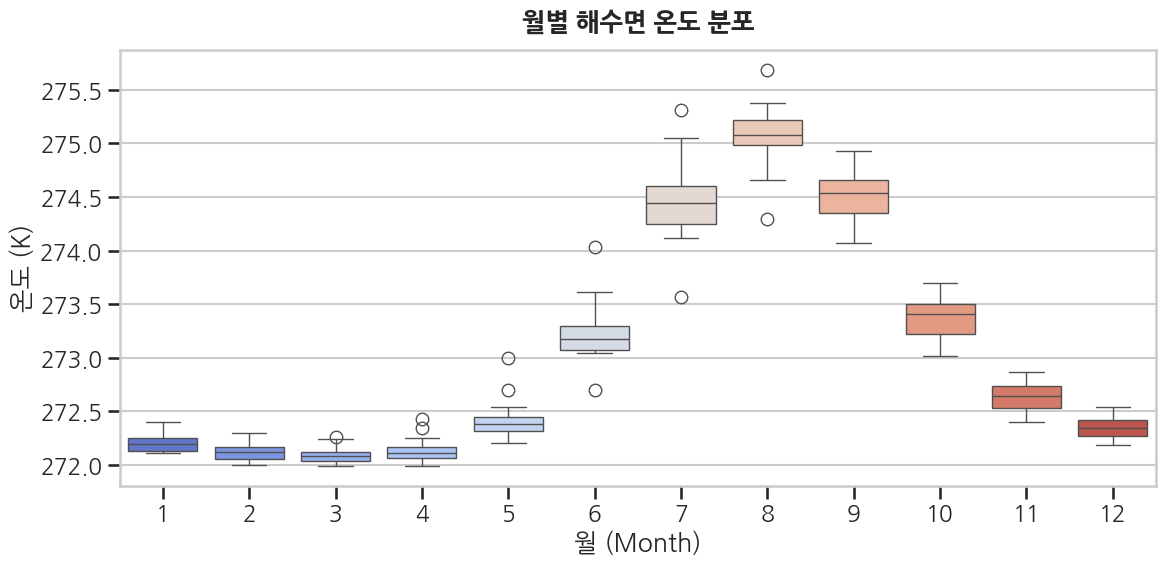

In [3]:
# [그래프 2] 월별 해수면 온도 분포 (계절성)
plt.figure(figsize=(12, 6))

# seaborn 박스 플롯 그리기
sns.boxplot(x='Month', y='TSKINWTR', data=df, palette='coolwarm')

# 완벽한 한글 제목과 축 이름 적용
plt.title('월별 해수면 온도 분포', fontweight='bold', pad=15)
plt.ylabel('온도 (K)')
plt.xlabel('월 (Month)')
plt.tight_layout()

plt.show()

[그래프 2]
- 8월 가장 뜨거움: 북극해의 수온은 2~4월에 최저점을 찍고, 8월에 최고점에 도달한다. 얼음이 다 녹고 바다가 태양빛을 가장 많이 흡수한 결과이다.

- 여름철의 이상 고온 현상: 6월, 7월, 8월 박스 위쪽에 찍힌 이상치에 주목해야 한다. 이는 평균적인 여름 수온을 훌쩍 뛰어넘는 '이례적인 폭염(해양 열파)'이 북극에 여러 번 발생했음을 의미한다.

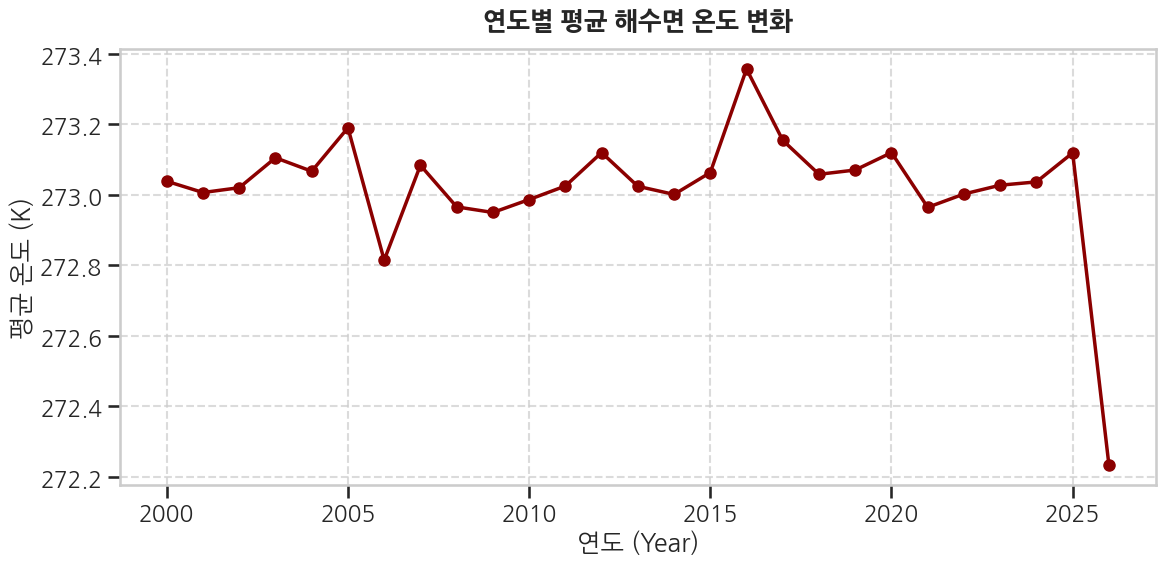

In [4]:
# [그래프 3] 연도별 평균 해수면 온도 변화 (온난화 추세 증거)
plt.figure(figsize=(12, 6))

yearly_mean = df.groupby('Year')['TSKINWTR'].mean()

plt.plot(yearly_mean.index, yearly_mean.values, marker='o', color='darkred', linestyle='-', linewidth=2.5, markersize=8)

plt.title('연도별 평균 해수면 온도 변화', fontweight='bold', pad=15)
plt.ylabel('평균 온도 (K)')
plt.xlabel('연도 (Year)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

[그래프 3]
- 특정 연도의 급상승: 평균 기온 추이를 보면 2005년, 2012년, 2016년에 북극해 수온이 눈에 띄게 급상승했다. (이 연도들에 북극 얼음이 대거 녹아내렸고, 유럽에 극심한 한파나 폭설이 닥쳤을 확률이 매우 높다.

** 맨 오른쪽 2026년에 그래프가 바닥으로 수직 추락한 것은 북극이 갑자기 추워진 것이 아니라 데이터가 2026년 5월까지만 존재하여 여름 데이터가 빠져있기 때문이다.


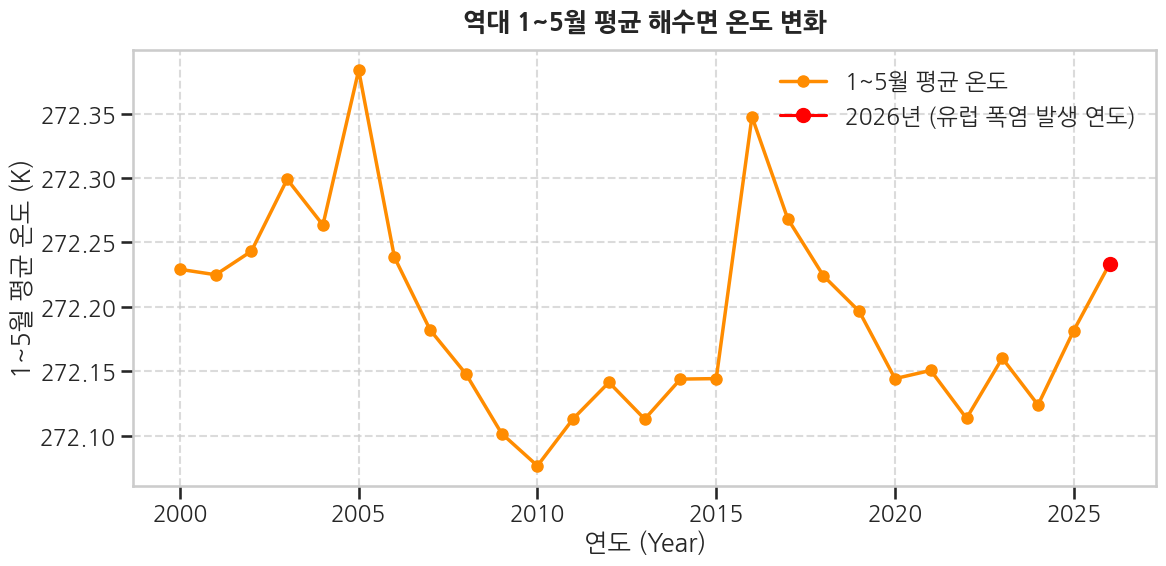

In [5]:
# [그래프 4] 역대 1~5월 평균 해수면 온도(SST) 추세
plt.figure(figsize=(12, 6))

# '1월부터 5월'까지의 데이터만 필터링
df_spring = df[df['Month'].isin([1, 2, 3, 4, 5])]

# 필터링된 데이터로 연도별 평균 계산
spring_yearly_mean = df_spring.groupby('Year')['TSKINWTR'].mean()

# 그래프
plt.plot(spring_yearly_mean.index, spring_yearly_mean.values,
         marker='o', color='darkorange', linestyle='-', linewidth=2.5, markersize=8, label='1~5월 평균 온도')

# 2026년 데이터 강조
plt.plot(2026, spring_yearly_mean.loc[2026], marker='o', color='red', markersize=10, label='2026년 (유럽 폭염 발생 연도)')


plt.title('역대 1~5월 평균 해수면 온도 변화', fontweight='bold', pad=15)
plt.ylabel('1~5월 평균 온도 (K)')
plt.xlabel('연도 (Year)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

[그래프 4]

- 2026년 봄철의 뚜렷한 수온 급상승: 2020~2025년 사이의 안정적인 하락 추세를 깨고, 2026년(빨간 점) 수온이 위로 튀어 올랐다.

- 폭염의 전조 증상: 역대급 기상이변이 잦았던 2005년, 2016년과 유사한 수준으로 올해 북극 바다가 예년보다 훨씬 일찍, 뜨겁게 달궈졌음을 알 수 있다.


※ 분석 기준 (1~5월 동기간 평균) 설정 사유

  통계적 오류 방지: 확보된 2026년 데이터가 5월까지만 존재하므로 과거 연도와의 비교 시 여름철(7~8월) 고온 데이터 누락으로 인한 평균값 왜곡을 막기 위함

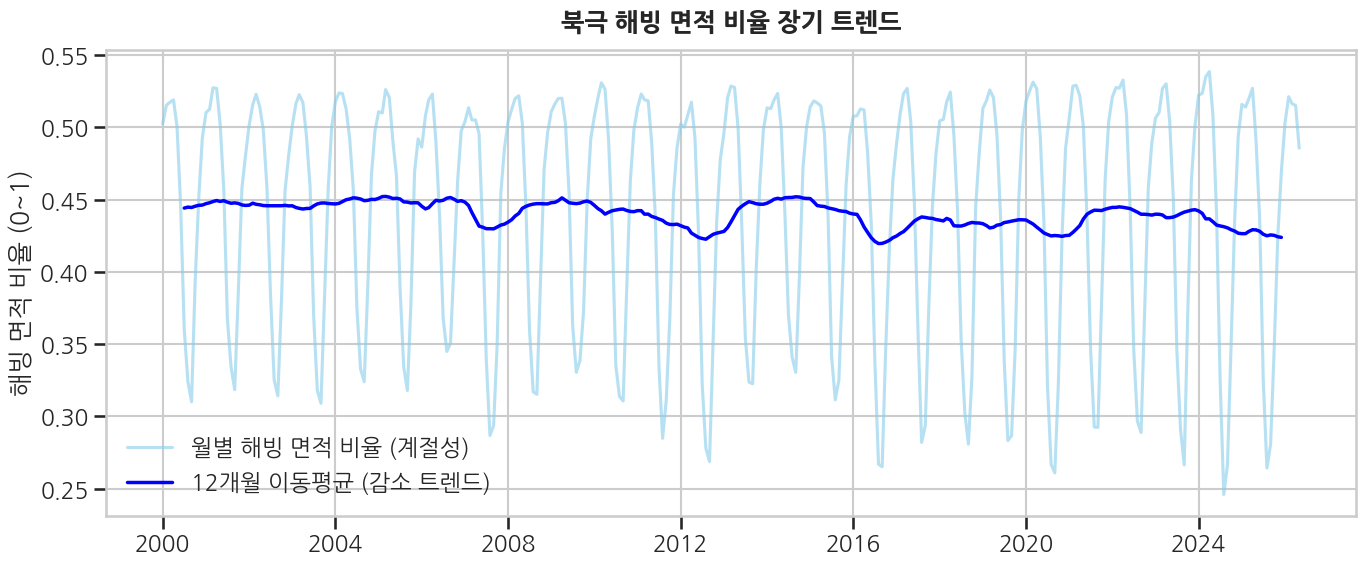

In [6]:
# [그래프 5] 북극 해빙 면적(FRSEAICE) 장기 트렌드 시각화
plt.figure(figsize=(14, 6))

# 12개월 이동평균 계산
df['FRSEAICE_roll'] = df['FRSEAICE'].rolling(window=12, center=True).mean()

# 얼음 데이터 시각화 (파란색 톤)
plt.plot(df.index, df['FRSEAICE'], color='skyblue', alpha=0.6, label='월별 해빙 면적 비율 (계절성)')
plt.plot(df.index, df['FRSEAICE_roll'], color='blue', linewidth=2.5, label='12개월 이동평균 (감소 트렌드)')

plt.title('북극 해빙 면적 비율 장기 트렌드', fontweight='bold', pad=15)
plt.ylabel('해빙 면적 비율 (0~1)')
plt.legend()
plt.tight_layout()
plt.show()

[그래프 5]
- 뚜렷한 얼음 감소 추세: 진한 파란색 선(12개월 이동평균)을 보면 2000년대 초반에 비해 현재로 올수록 전체적인 해빙 면적이 우하향하며 지속적으로 감소하고 있다.

- 극단적인 해빙 감소 연도: 특히 2007년, 2012년, 2016년, 2020년경에 얼음 면적이 급격히 바닥을 치는 현상(V자 계곡)이 관찰된다. 이는 해당 연도들의 수온 급상승 데이터(이전 그래프)와 일치하며 이 시기에 북극 생태계에 심각한 타격을 입었음을 보여준다.

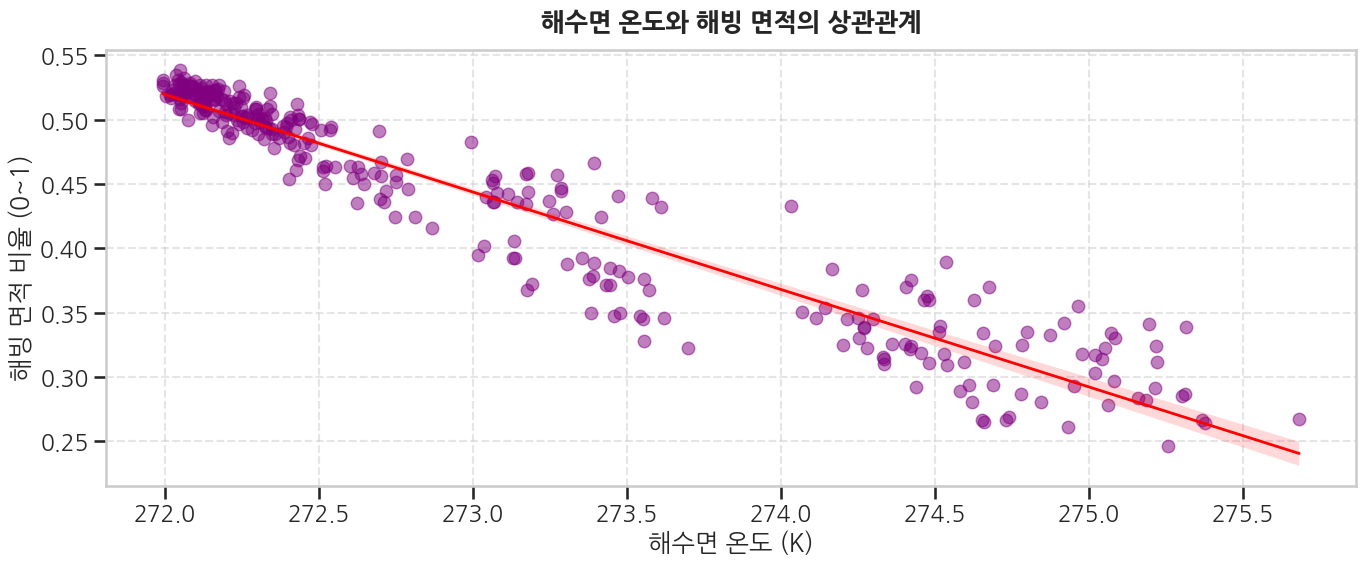

In [7]:
# [그래프 6] 수온과 해빙 면적의 상관관계
plt.figure(figsize=(14, 6))

# 산점도 및 추세선
sns.regplot(x='TSKINWTR', y='FRSEAICE', data=df,
            scatter_kws={'alpha':0.5, 'color':'purple'},
            line_kws={'color':'red', 'linewidth':2})

plt.title('해수면 온도와 해빙 면적의 상관관계', fontweight='bold', pad=15)
plt.xlabel('해수면 온도 (K)')
plt.ylabel('해빙 면적 비율 (0~1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

[그래프 6]

- 강력한 음(-)의 상관관계: 빨간색 추세선이 뚜렷하게 우하향하고 있다. 이는 '해수면 온도가 높아질수록 해빙 면적은 기하급수적으로 줄어든다'는 가설을 시각적으로 증명한다.

- 데이터의 밀집도: 점들이 흩어지지 않고 빨간 추세선 주변에 모여 있다는 것은 온도 상승이 얼음 감소에 미치는 영향력이 통계적으로 매우 강력하다는 것을 보여준다.